# Customer Churn Prediction
## Playground Series S6E3

---

**Task:** Binary classification - predict whether a telecom customer will churn

**Metric:** ROC-AUC

**Approach:**
- EDA & Feature Engineering
- XGBoost + LightGBM + CatBoost Ensemble
- Optuna Hyperparameter Tuning
- StratifiedKFold Cross-Validation

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import warnings
warnings.filterwarnings('ignore')

print("All imports done!")

All imports done!


venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Load Data

In [2]:
DATA_DIR = './data'
OUTPUT_DIR = './output'

# Create output directory if it doesn't exist
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

train = pd.read_csv(f'{DATA_DIR}/train.csv')
test = pd.read_csv(f'{DATA_DIR}/test.csv')
sample_sub = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')

# Convert Churn to numeric (Yes=1, No=0) - handles both string and numeric
train['Churn'] = train['Churn'].map({'Yes': 1, 'No': 0}).fillna(train['Churn']).astype(int)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Submission shape: {sample_sub.shape}")
print(f"\nTarget distribution:")
print(train['Churn'].value_counts(normalize=True))
print(f"\nTrain columns: {train.columns.tolist()}")

Train shape: (594194, 21)
Test shape: (254655, 20)
Submission shape: (254655, 2)

Target distribution:
Churn
0    0.774792
1    0.225208
Name: proportion, dtype: float64

Train columns: ['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
print("=" * 60)
print("DATA OVERVIEW")
print("=" * 60)
print(f"\nFirst 5 rows:")
train.head()

DATA OVERVIEW

First 5 rows:


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1


In [4]:
print("Data types:")
print(train.dtypes)
print(f"\nMissing values:")
print(train.isnull().sum())
print(f"\nBasic stats:")
train.describe()

Data types:
id                    int64
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

Missing values:
id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling 

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057,0.225208
std,171529.177263,0.317936,25.061922,31.067444,2353.916710,0.417719
min,0.000000,0.000000,1.000000,18.250000,18.800000,0.000000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000,0.000000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000,0.000000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000,0.000000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000,1.000000


## Step 2: EDA & Visualization

In [5]:
# Identify column types
target = 'Churn'
id_col = 'id'

cat_cols = [c for c in train.select_dtypes(include='object').columns.tolist()
            if c not in [id_col, target]]
num_cols = [c for c in train.select_dtypes(include=[np.number]).columns.tolist() 
            if c not in [id_col, target]]

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical columns ({len(num_cols)}): {num_cols}")

Categorical columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


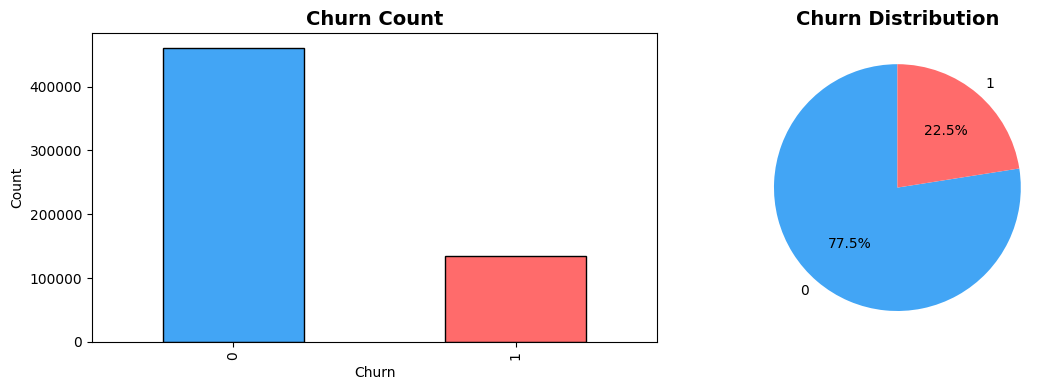

In [6]:
# Visualization 1: Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train[target].value_counts().plot.bar(ax=axes[0], color=['#42a5f5', '#ff6b6b'], edgecolor='black')
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')

train[target].value_counts().plot.pie(ax=axes[1], autopct='%1.1f%%', colors=['#42a5f5', '#ff6b6b'],
                                      startangle=90)
axes[1].set_title('Churn Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

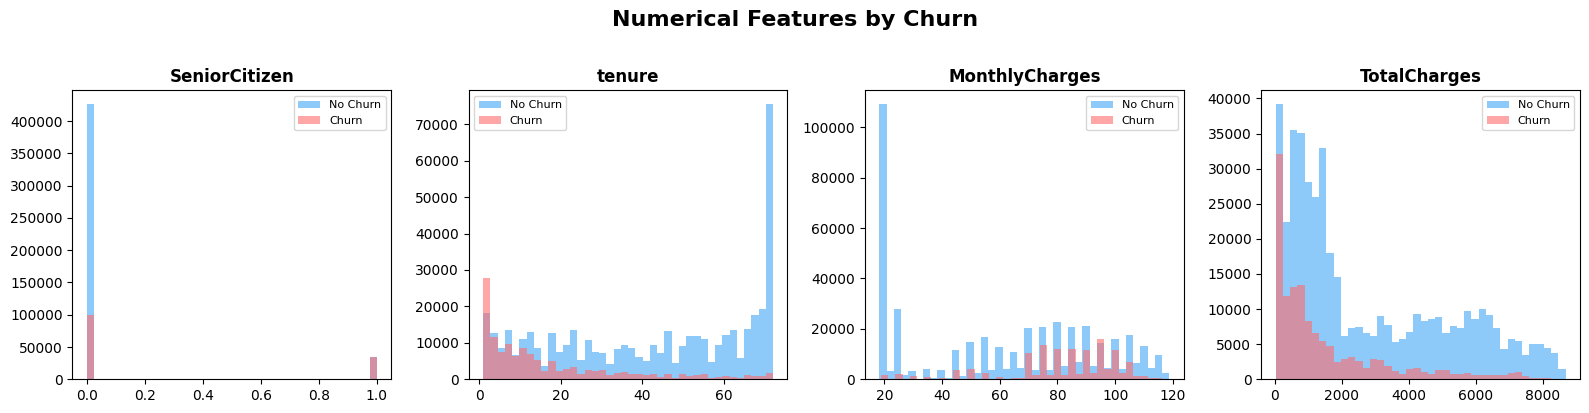

In [7]:
# Visualization 2: Numerical feature distributions
if len(num_cols) > 0:
    n_cols_plot = min(len(num_cols), 8)
    n_rows = (n_cols_plot + 3) // 4
    fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(num_cols[:n_cols_plot]):
        axes[i].hist(train[train[target] == 0][col], bins=40, alpha=0.6, label='No Churn', color='#42a5f5')
        axes[i].hist(train[train[target] == 1][col], bins=40, alpha=0.6, label='Churn', color='#ff6b6b')
        axes[i].set_title(col, fontweight='bold')
        axes[i].legend(fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Numerical Features by Churn', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/numerical_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

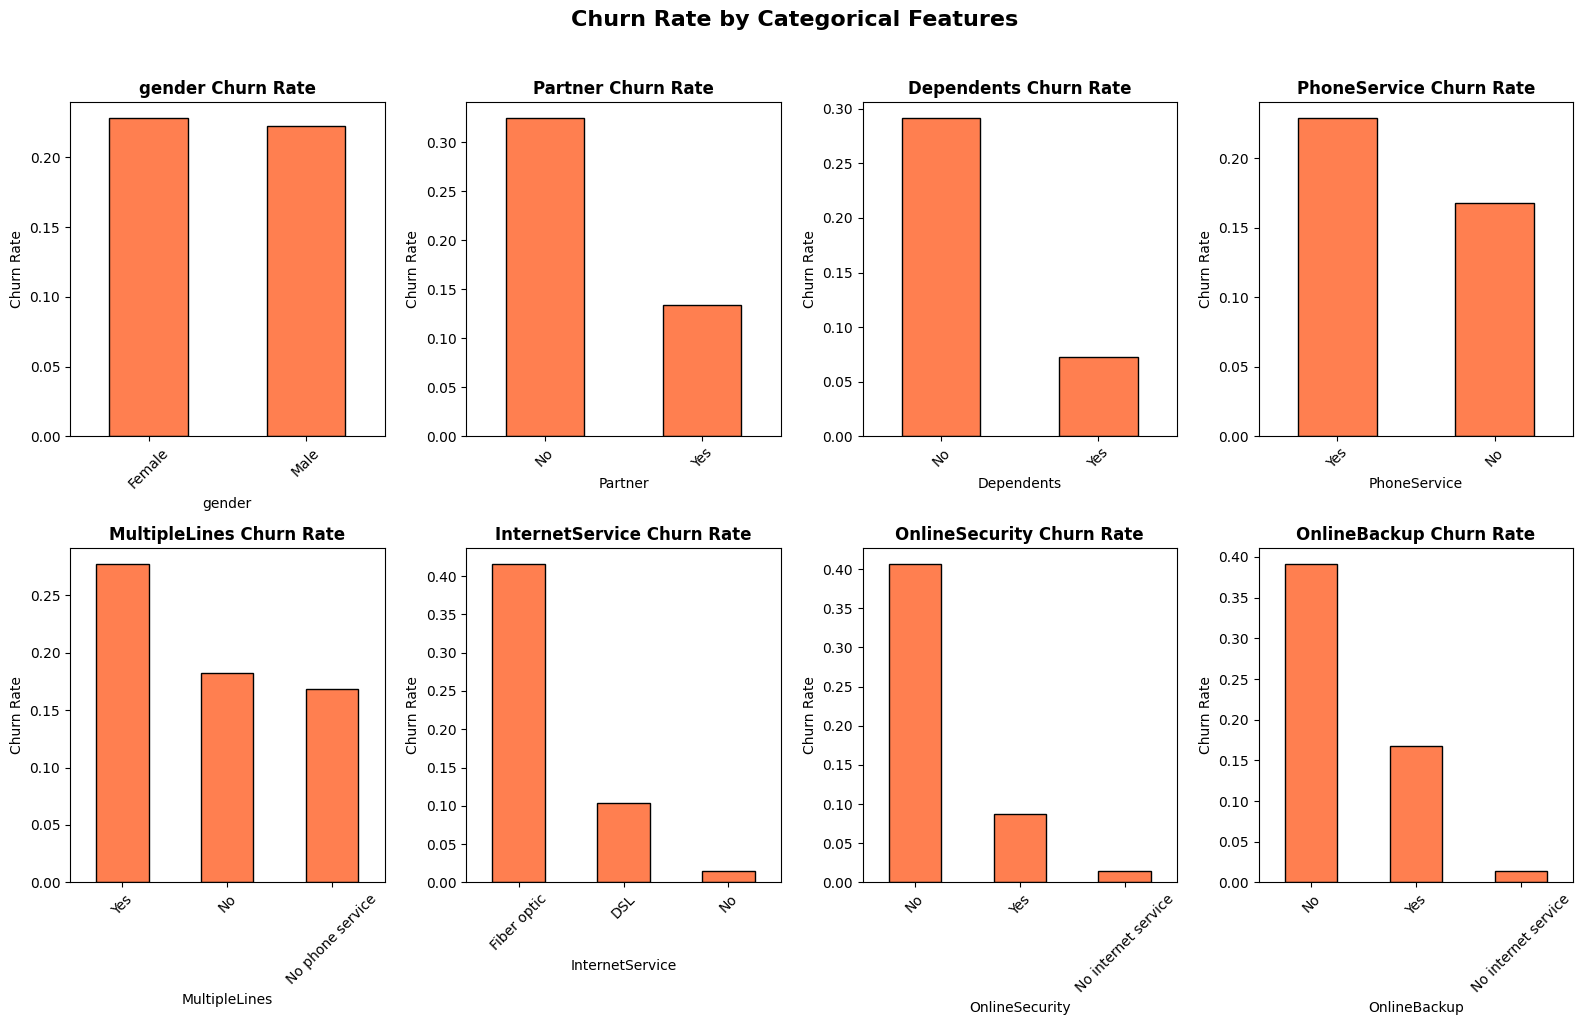

In [8]:
# Visualization 3: Categorical feature vs churn
if len(cat_cols) > 0:
    n_cols_plot = min(len(cat_cols), 8)
    n_rows = (n_cols_plot + 3) // 4
    fig, axes = plt.subplots(n_rows, 4, figsize=(16, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols[:n_cols_plot]):
        churn_rates = train.groupby(col)[target].mean().sort_values(ascending=False)
        churn_rates.plot.bar(ax=axes[i], color='coral', edgecolor='black')
        axes[i].set_title(f'{col} Churn Rate', fontweight='bold')
        axes[i].set_ylabel('Churn Rate')
        axes[i].tick_params(axis='x', rotation=45)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/categorical_churn_rates.png', dpi=150, bbox_inches='tight')
    plt.show()

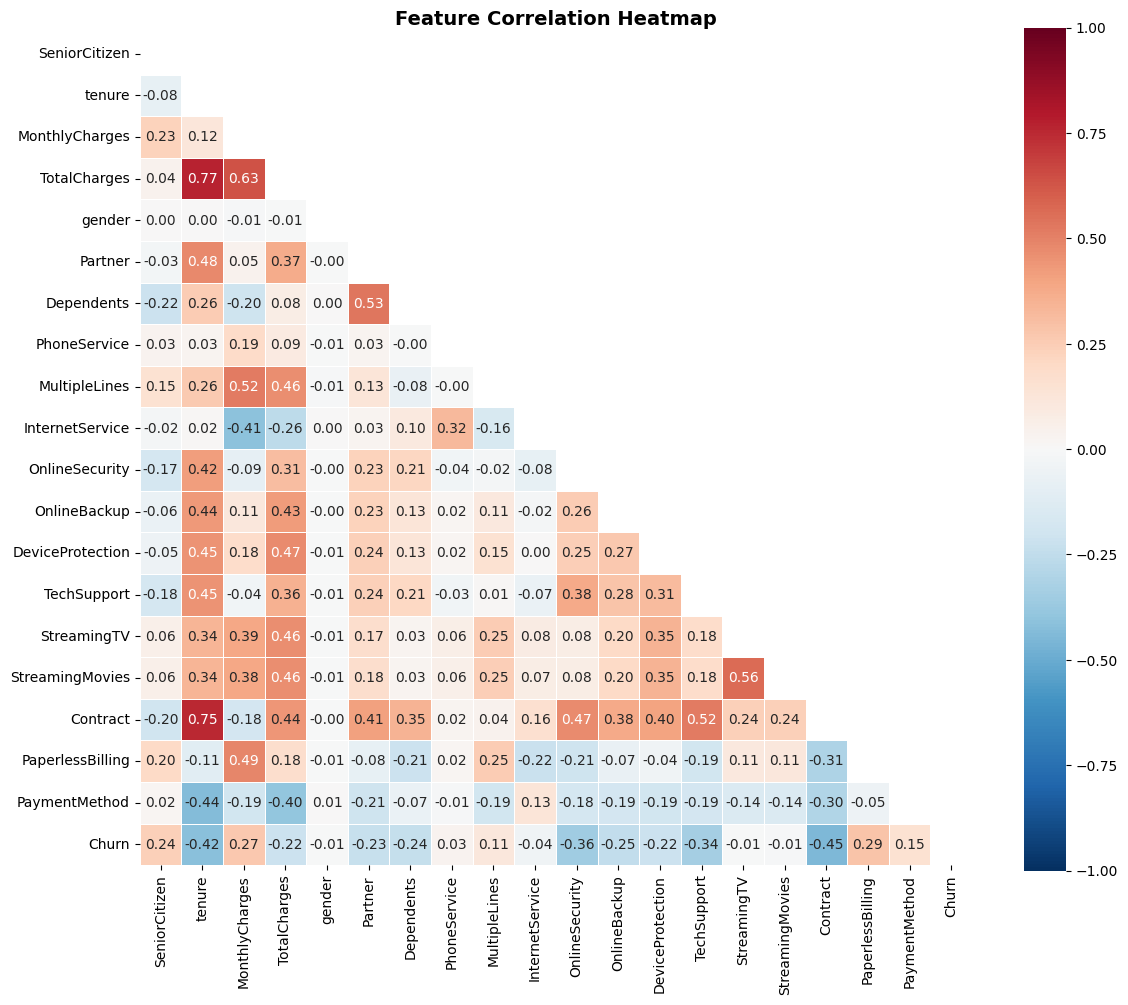


Top correlations with Churn:
Contract            0.449285
tenure              0.418453
OnlineSecurity      0.356786
TechSupport         0.342550
PaperlessBilling    0.285107
MonthlyCharges      0.272997
OnlineBackup        0.246620
Dependents          0.240369
SeniorCitizen       0.236362
Partner             0.228212
Name: Churn, dtype: float64


In [9]:
# Visualization 4: Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Encode categoricals temporarily for correlation
train_encoded = train.copy()
for col in cat_cols:
    train_encoded[col] = LabelEncoder().fit_transform(train_encoded[col].astype(str))

corr_cols = num_cols + cat_cols + [target]
corr = train_encoded[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
           square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with target
print("\nTop correlations with Churn:")
target_corr = corr[target].drop(target).abs().sort_values(ascending=False)
print(target_corr.head(10))

### EDA Summary
- ~22.5% churn rate (imbalanced)
- Key features likely: Contract type, Tenure, Monthly charges, Internet service
- Categorical features need encoding
- Feature engineering opportunities: interaction terms, tenure buckets

## Step 3: Feature Engineering

In [10]:
def feature_engineering(df):
    """Apply feature engineering to train and test"""
    df = df.copy()
    
    # Tenure buckets
    if 'tenure' in df.columns:
        df['tenure_bucket'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72, 999],
                                     labels=[0, 1, 2, 3, 4]).astype(int)
    
    # Monthly charges per tenure month
    if 'MonthlyCharges' in df.columns and 'tenure' in df.columns:
        df['charges_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)
    
    # Total charges ratio
    if 'TotalCharges' in df.columns and 'MonthlyCharges' in df.columns:
        df['total_monthly_ratio'] = df['TotalCharges'] / (df['MonthlyCharges'] + 1)
    
    # Number of services
    service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies']
    existing_service_cols = [c for c in service_cols if c in df.columns]
    if existing_service_cols:
        for col in existing_service_cols:
            df[f'{col}_flag'] = (df[col] == 'Yes').astype(int) if df[col].dtype == 'object' else 0
        flag_cols = [f'{c}_flag' for c in existing_service_cols]
        df['num_services'] = df[flag_cols].sum(axis=1)
        df.drop(columns=flag_cols, inplace=True)
    
    # Has partner and dependents
    if 'Partner' in df.columns and 'Dependents' in df.columns:
        df['has_family'] = ((df['Partner'] == 'Yes') | (df['Dependents'] == 'Yes')).astype(int)
    
    # Additional interaction terms
    if 'MonthlyCharges' in df.columns and 'Contract' in df.columns:
        df['high_monthly_short_contract'] = ((df['MonthlyCharges'] > df['MonthlyCharges'].median()) & 
                                             (df['Contract'] == 'Month-to-month')).astype(int)
    
    if 'tenure' in df.columns and 'InternetService' in df.columns:
        df['long_tenure_fiber'] = ((df['tenure'] > 24) & (df['InternetService'] == 'Fiber optic')).astype(int)
    
    return df

train_fe = feature_engineering(train)
test_fe = feature_engineering(test)

print(f"Train after FE: {train_fe.shape}")
print(f"Test after FE: {test_fe.shape}")
print(f"New columns: {[c for c in train_fe.columns if c not in train.columns]}")

Train after FE: (594194, 28)
Test after FE: (254655, 27)
New columns: ['tenure_bucket', 'charges_per_tenure', 'total_monthly_ratio', 'num_services', 'has_family', 'high_monthly_short_contract', 'long_tenure_fiber']


In [11]:
# Encode categorical features
label_encoders = {}

# Update cat_cols after FE
cat_cols_fe = train_fe.select_dtypes(include='object').columns.tolist()

for col in cat_cols_fe:
    le = LabelEncoder()
    # Fit on combined train+test to handle unseen categories
    combined = pd.concat([train_fe[col].astype(str), test_fe[col].astype(str)])
    le.fit(combined)
    train_fe[col] = le.transform(train_fe[col].astype(str))
    test_fe[col] = le.transform(test_fe[col].astype(str))
    label_encoders[col] = le

print(f"Encoded {len(cat_cols_fe)} categorical columns: {cat_cols_fe}")

# Handle missing values
train_fe = train_fe.fillna(-1)
test_fe = test_fe.fillna(-1)

# Prepare features
drop_cols = [id_col, target]
feature_cols = [c for c in train_fe.columns if c not in drop_cols]

X = train_fe[feature_cols].values
y = train_fe[target].values
X_test = test_fe[feature_cols].values

print(f"\nFeatures: {len(feature_cols)}")
print(f"X shape: {X.shape}")
print(f"X_test shape: {X_test.shape}")

Encoded 15 categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Features: 26
X shape: (594194, 26)
X_test shape: (254655, 26)


## Step 4: Model Training (XGBoost + LightGBM + CatBoost)

In [12]:
# XGBoost with Optuna tuning
N_FOLDS = 5
SEED = 42

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 5),
        'random_state': SEED,
        'eval_metric': 'auc',
        'tree_method': 'hist',
    }
    
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        
        model = xgb.XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=0)
        
        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))
    
    return np.mean(scores)

print("Starting XGBoost Optuna tuning (50 trials)...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print(f"\nBest XGBoost AUC: {study_xgb.best_value:.6f}")
print(f"Best params: {study_xgb.best_params}")

Starting XGBoost Optuna tuning (50 trials)...


Best trial: 43. Best value: 0.91615: 100%|██████████| 50/50 [1:04:05<00:00, 76.91s/it]


Best XGBoost AUC: 0.916150
Best params: {'n_estimators': 817, 'max_depth': 5, 'learning_rate': 0.05750161340209875, 'subsample': 0.7733652652049131, 'colsample_bytree': 0.7430299429413, 'min_child_weight': 3, 'reg_alpha': 0.010533958827351841, 'reg_lambda': 0.0002990092403725652, 'gamma': 2.6570245103062096, 'scale_pos_weight': 3.179969959805805}


In [13]:
# LightGBM with Optuna tuning
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'random_state': SEED,
        'verbose': -1,
    }
    
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        
        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.log_evaluation(0)])
        
        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))
    
    return np.mean(scores)

print("Starting LightGBM Optuna tuning (50 trials)...")
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=50, show_progress_bar=True)

print(f"\nBest LightGBM AUC: {study_lgb.best_value:.6f}")
print(f"Best params: {study_lgb.best_params}")

Starting LightGBM Optuna tuning (50 trials)...


Best trial: 44. Best value: 0.916457: 100%|██████████| 50/50 [40:21<00:00, 48.42s/it]


Best LightGBM AUC: 0.916457
Best params: {'n_estimators': 1180, 'max_depth': 4, 'learning_rate': 0.10697197309175127, 'subsample': 0.7098253361016321, 'colsample_bytree': 0.732472975597933, 'min_child_samples': 45, 'reg_alpha': 7.281440637786079, 'reg_lambda': 1.3267724868185596e-08, 'num_leaves': 58}


In [14]:
# CatBoost with Optuna tuning
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1500),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.1, 50.0, log=True),  # Increased from 1e-8
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 100),
        'random_seed': SEED,
        'verbose': 0,
        'eval_metric': 'AUC',
    }
    
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        
        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=0)
        
        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))
    
    return np.mean(scores)

print("Starting CatBoost Optuna tuning (50 trials)...")
study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=50, show_progress_bar=True)

print(f"\nBest CatBoost AUC: {study_cat.best_value:.6f}")
print(f"Best params: {study_cat.best_params}")

Starting CatBoost Optuna tuning (50 trials)...


Best trial: 18. Best value: 0.916412: 100%|██████████| 50/50 [1:56:08<00:00, 139.37s/it]  


Best CatBoost AUC: 0.916412
Best params: {'iterations': 1304, 'depth': 6, 'learning_rate': 0.07600997624398846, 'l2_leaf_reg': 5.561364510401154, 'subsample': 0.9320278012449009, 'colsample_bylevel': 0.7977694221210929, 'min_data_in_leaf': 69}


## Step 5: Final Training & Ensemble

In [15]:
# Train final models with best params using KFold
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_xgb = np.zeros(len(X))
oof_lgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))

test_preds_xgb = np.zeros(len(X_test))
test_preds_lgb = np.zeros(len(X_test))
test_preds_cat = np.zeros(len(X_test))

xgb_params = {**study_xgb.best_params, 'random_state': SEED, 'eval_metric': 'auc', 'tree_method': 'hist'}
lgb_params = {**study_lgb.best_params, 'random_state': SEED, 'verbose': -1}
cat_params = {**study_cat.best_params, 'random_seed': SEED, 'verbose': 0, 'eval_metric': 'AUC'}

print("Training final models with best hyperparameters...")
print("=" * 60)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    # XGBoost
    xgb_model = xgb.XGBClassifier(**xgb_params)
    xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=0)
    oof_xgb[val_idx] = xgb_model.predict_proba(X_val)[:, 1]
    test_preds_xgb += xgb_model.predict_proba(X_test)[:, 1] / N_FOLDS
    
    # LightGBM
    lgb_model = lgb.LGBMClassifier(**lgb_params)
    lgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.log_evaluation(0)])
    oof_lgb[val_idx] = lgb_model.predict_proba(X_val)[:, 1]
    test_preds_lgb += lgb_model.predict_proba(X_test)[:, 1] / N_FOLDS
    
    # CatBoost
    cat_model = CatBoostClassifier(**cat_params)
    cat_model.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=0)
    oof_cat[val_idx] = cat_model.predict_proba(X_val)[:, 1]
    test_preds_cat += cat_model.predict_proba(X_test)[:, 1] / N_FOLDS
    
    xgb_auc = roc_auc_score(y_val, oof_xgb[val_idx])
    lgb_auc = roc_auc_score(y_val, oof_lgb[val_idx])
    cat_auc = roc_auc_score(y_val, oof_cat[val_idx])
    
    print(f"Fold {fold+1} - XGB: {xgb_auc:.6f} | LGB: {lgb_auc:.6f} | CAT: {cat_auc:.6f}")

# Overall OOF scores
print(f"\n{'='*60}")
print(f"Overall OOF AUC:")
print(f"  XGBoost:  {roc_auc_score(y, oof_xgb):.6f}")
print(f"  LightGBM: {roc_auc_score(y, oof_lgb):.6f}")
print(f"  CatBoost: {roc_auc_score(y, oof_cat):.6f}")

# Ensemble (simple average)
oof_ensemble = (oof_xgb + oof_lgb + oof_cat) / 3
test_ensemble = (test_preds_xgb + test_preds_lgb + test_preds_cat) / 3
print(f"  Ensemble: {roc_auc_score(y, oof_ensemble):.6f}")

Training final models with best hyperparameters...
Fold 1 - XGB: 0.915701 | LGB: 0.916061 | CAT: 0.916038
Fold 2 - XGB: 0.916898 | LGB: 0.917207 | CAT: 0.917253
Fold 3 - XGB: 0.916368 | LGB: 0.916579 | CAT: 0.916429
Fold 4 - XGB: 0.917293 | LGB: 0.917584 | CAT: 0.917552
Fold 5 - XGB: 0.914488 | LGB: 0.914854 | CAT: 0.914788

Overall OOF AUC:
  XGBoost:  0.916141
  LightGBM: 0.916449
  CatBoost: 0.916403
  Ensemble: 0.916648


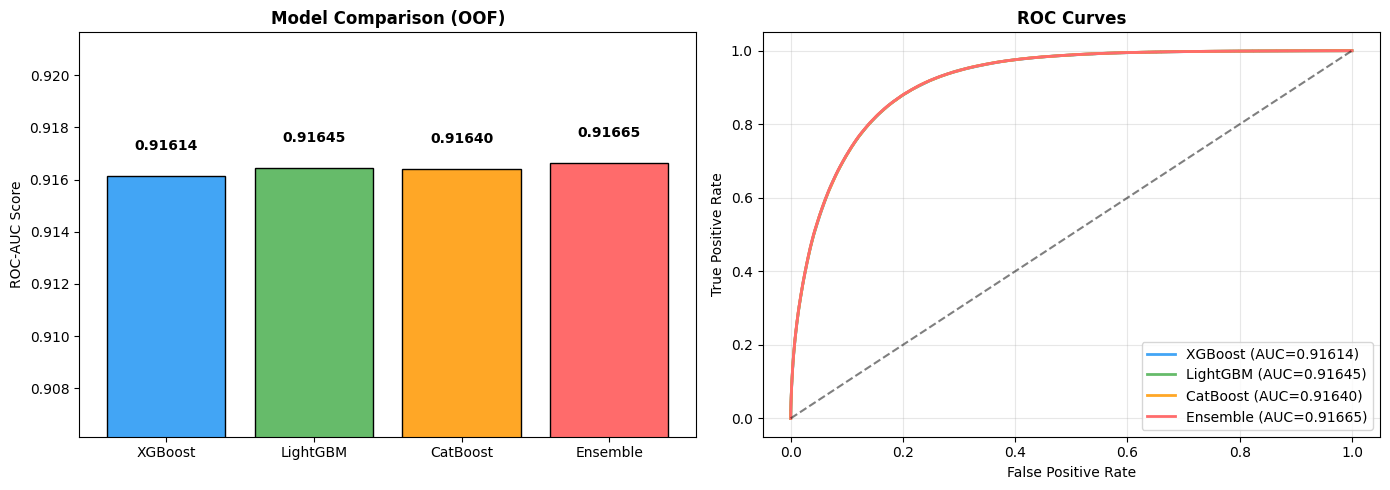

In [16]:
# Visualization 5: Model comparison & ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Model comparison bar
model_names = ['XGBoost', 'LightGBM', 'CatBoost', 'Ensemble']
model_scores = [
    roc_auc_score(y, oof_xgb),
    roc_auc_score(y, oof_lgb),
    roc_auc_score(y, oof_cat),
    roc_auc_score(y, oof_ensemble)
]
colors = ['#42a5f5', '#66bb6a', '#ffa726', '#ff6b6b']
bars = axes[0].bar(model_names, model_scores, color=colors, edgecolor='black')
axes[0].set_ylabel('ROC-AUC Score')
axes[0].set_title('Model Comparison (OOF)', fontweight='bold')
axes[0].set_ylim(min(model_scores) - 0.01, max(model_scores) + 0.005)
for bar, score in zip(bars, model_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
               f'{score:.5f}', ha='center', fontweight='bold')

# ROC curves
for name, oof_preds, color in zip(
    ['XGBoost', 'LightGBM', 'CatBoost', 'Ensemble'],
    [oof_xgb, oof_lgb, oof_cat, oof_ensemble],
    colors
):
    fpr, tpr, _ = roc_curve(y, oof_preds)
    auc = roc_auc_score(y, oof_preds)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.5f})', color=color, linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

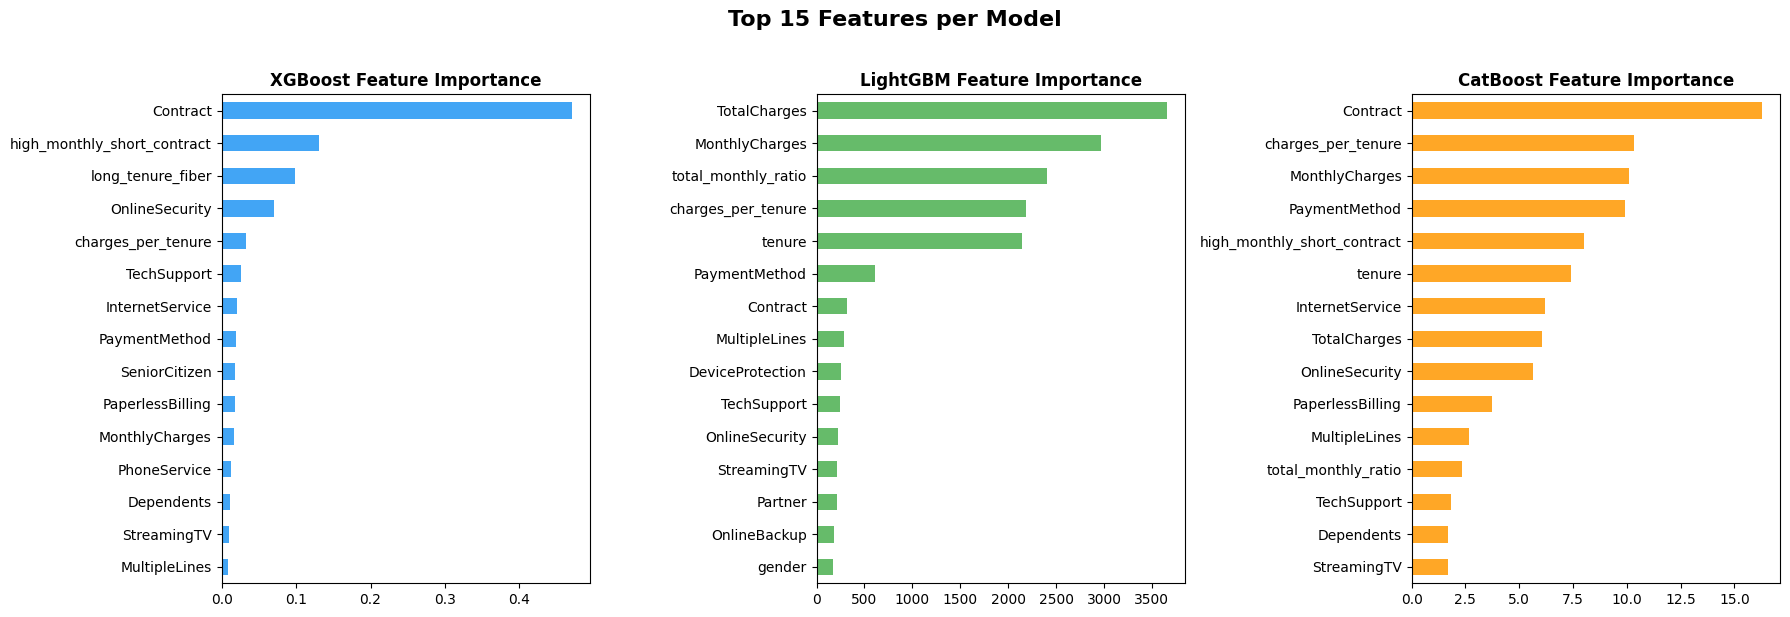

In [17]:
# Visualization 6: Feature importance
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# XGBoost importance
xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
xgb_imp.tail(15).plot.barh(ax=axes[0], color='#42a5f5')
axes[0].set_title('XGBoost Feature Importance', fontweight='bold')

# LightGBM importance
lgb_imp = pd.Series(lgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
lgb_imp.tail(15).plot.barh(ax=axes[1], color='#66bb6a')
axes[1].set_title('LightGBM Feature Importance', fontweight='bold')

# CatBoost importance
cat_imp = pd.Series(cat_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
cat_imp.tail(15).plot.barh(ax=axes[2], color='#ffa726')
axes[2].set_title('CatBoost Feature Importance', fontweight='bold')

plt.suptitle('Top 15 Features per Model', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Submission

Submission saved!
Shape: (254655, 2)

Prediction distribution:
count    254655.000000
mean          0.256285
std           0.295805
min           0.000268
25%           0.010465
50%           0.099229
75%           0.485340
max           0.992930
Name: Churn, dtype: float64


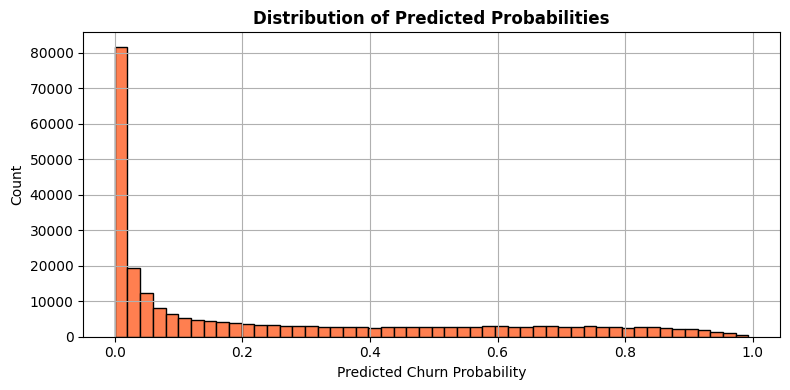


First 10 predictions:


,id,Churn
0,594194,0.125951
1,594195,0.001048
2,594196,0.158260
3,594197,0.005375
4,594198,0.582417
5,594199,0.253123
6,594200,0.918187
7,594201,0.003360
8,594202,0.053858
9,594203,0.416696


In [18]:
# Create submission
submission = sample_sub.copy()
submission['Churn'] = test_ensemble

submission.to_csv(f'{OUTPUT_DIR}/submission.csv', index=False)

print(f"Submission saved!")
print(f"Shape: {submission.shape}")
print(f"\nPrediction distribution:")
print(submission['Churn'].describe())

fig, ax = plt.subplots(figsize=(8, 4))
submission['Churn'].hist(bins=50, ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Count')
ax.set_title('Distribution of Predicted Probabilities', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/prediction_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFirst 10 predictions:")
submission.head(10)

---

## Conclusion

### What this notebook does:
- EDA with 6 visualizations (target, numerical, categorical, correlation, ROC curves, feature importance)
- Feature engineering (tenure buckets, charge ratios, service counts, family flag)
- 3 models tuned with Optuna (50 trials each): XGBoost, LightGBM, CatBoost
- 5-Fold StratifiedKFold cross-validation
- Simple average ensemble
- Submission file generation

**Authored by Pratik**